Importing libraries

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Loading the dataset

In [33]:

df = pd.read_csv(
    "Metro_Interstate_Traffic_Volume.csv"
)

print("Shape:", df.shape)

df.head()

Shape: (48204, 9)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


Basic information

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     str    
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  str    
 6   weather_description  48204 non-null  str    
 7   date_time            48204 non-null  str    
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), str(4)
memory usage: 3.3 MB


Statistical summary

In [35]:
df.describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


Missing Values

In [36]:
print(df.isnull().sum())

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64


Convert date and time features

In [37]:
df["date_time"] = pd.to_datetime(df["date_time"])

df["hour"] = df["date_time"].dt.hour
df["day_of_week"] = df["date_time"].dt.dayofweek
df["month"] = df["date_time"].dt.month

Traffic volume distrubution

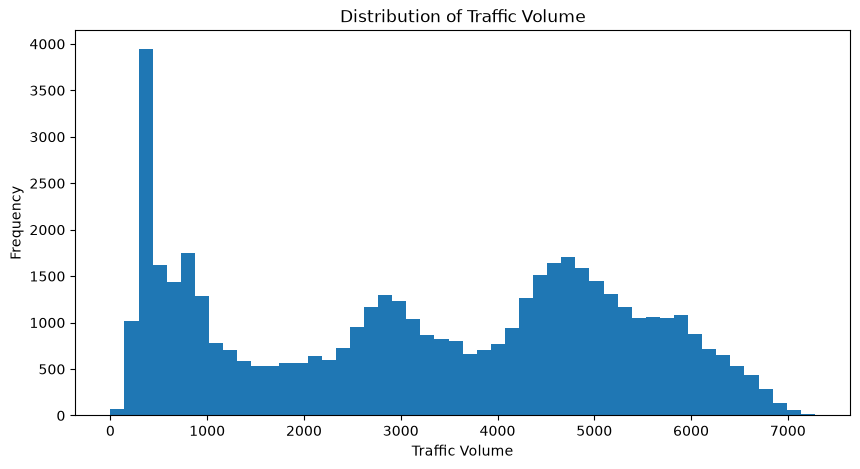

In [38]:
plt.figure(figsize=(10, 5))

plt.hist(df["traffic_volume"], bins=50)

plt.xlabel("Traffic Volume")
plt.ylabel("Frequency")
plt.title("Distribution of Traffic Volume")

plt.show()

Traffic by hour

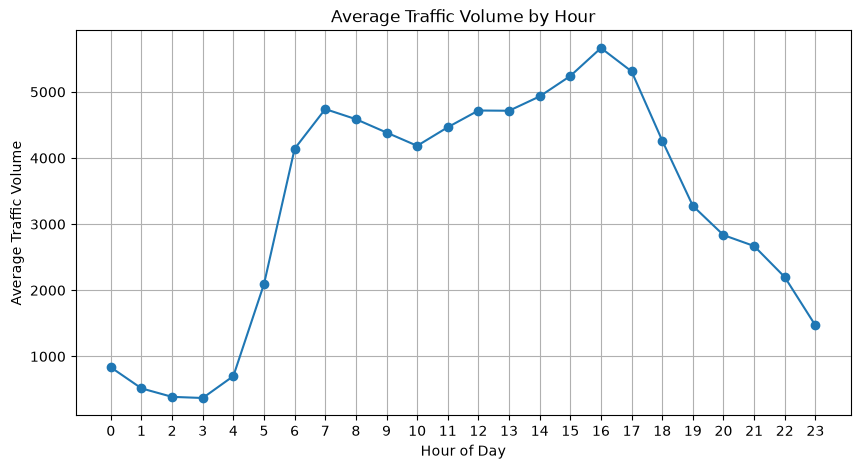

In [39]:
hourly_traffic = df.groupby("hour")["traffic_volume"].mean()

plt.figure(figsize=(10, 5))

plt.plot(hourly_traffic.index, hourly_traffic.values, marker="o")

plt.xlabel("Hour of Day")
plt.ylabel("Average Traffic Volume")
plt.title("Average Traffic Volume by Hour")

plt.xticks(range(24))
plt.grid()

plt.show()

Traffic by month

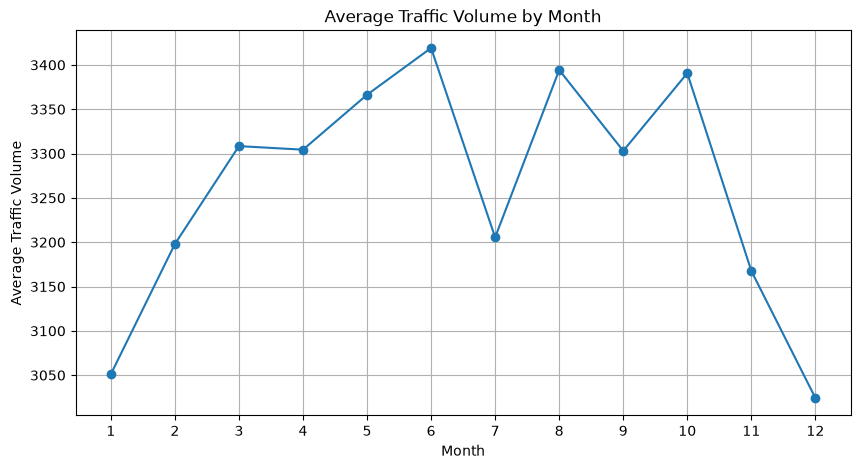

In [40]:
monthly_traffic = df.groupby("month")["traffic_volume"].mean()

plt.figure(figsize=(10, 5))

plt.plot(monthly_traffic.index, monthly_traffic.values, marker="o")

plt.xlabel("Month")
plt.ylabel("Average Traffic Volume")
plt.title("Average Traffic Volume by Month")

plt.xticks(range(1, 13))
plt.grid()

plt.show()

Correlation Analyis

traffic_volume    1.000000
hour              0.352401
temp              0.130299
clouds_all        0.067054
rain_1h           0.004714
snow_1h           0.000733
month            -0.002533
day_of_week      -0.149544
Name: traffic_volume, dtype: float64


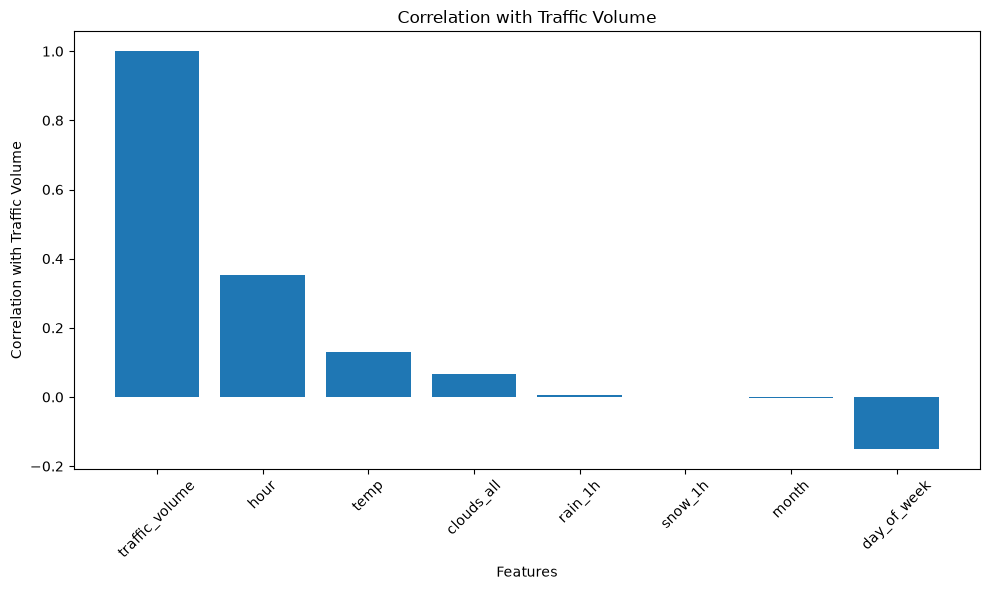

In [41]:
numeric_df = df.select_dtypes(include="number")

correlation = numeric_df.corr()["traffic_volume"].sort_values(
    ascending=False
)

print(correlation)
plt.figure(figsize=(10, 6))

plt.bar(
    correlation.index,
    correlation.values
)

plt.xlabel("Features")
plt.ylabel("Correlation with Traffic Volume")
plt.title("Correlation with Traffic Volume")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()